In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron


In [3]:
df = pd.read_csv("../data/golf.csv")

In [4]:
df.head(15)

,Outlook,Temp,Humidity,Windy,Play Golf
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes
5,Sunny,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Rainy,Mild,High,False,No
8,Rainy,Cool,Normal,False,Yes
9,Sunny,Mild,Normal,False,Yes


One-Hot Encoder

In [6]:
columns_to_encode = ['Outlook', 'Temp', 'Humidity', 'Windy']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[columns_to_encode])
df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), df_encoded], axis=1)
df

,Play Golf,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Temp_Cool,Temp_Hot,Temp_Mild,Humidity_High,Humidity_Normal,Windy_False,Windy_True
0,No,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,No,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,Yes,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,Yes,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,Yes,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5,No,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
6,Yes,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
7,No,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
8,Yes,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
9,Yes,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


Train/Test split

In [7]:
x = df.drop(columns=['Play Golf'])
y = df['Play Golf']

NN Classifier

In [10]:
model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=2000, random_state=42, verbose=True)
model.fit(x, y)

Iteration 1, loss = 1.00581882
Iteration 2, loss = 0.99997545
Iteration 3, loss = 0.99417498
Iteration 4, loss = 0.98841830
Iteration 5, loss = 0.98270623
Iteration 6, loss = 0.97703960
Iteration 7, loss = 0.97141917
Iteration 8, loss = 0.96584565
Iteration 9, loss = 0.96035158
Iteration 10, loss = 0.95513990
Iteration 11, loss = 0.95000113
Iteration 12, loss = 0.94491763
Iteration 13, loss = 0.93988794
Iteration 14, loss = 0.93491093
Iteration 15, loss = 0.92998569
Iteration 16, loss = 0.92511146
Iteration 17, loss = 0.92028764
Iteration 18, loss = 0.91555166
Iteration 19, loss = 0.91089369
Iteration 20, loss = 0.90627622
Iteration 21, loss = 0.90170114
Iteration 22, loss = 0.89716966
Iteration 23, loss = 0.89268260
Iteration 24, loss = 0.88824059
Iteration 25, loss = 0.88384407
Iteration 26, loss = 0.87949336
Iteration 27, loss = 0.87518866
Iteration 28, loss = 0.87093012
Iteration 29, loss = 0.86671778
Iteration 30, loss = 0.86255162
Iteration 31, loss = 0.85855785
Iteration 32, los

,hidden_layer_sizes,"(5,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


In [16]:
model.score(x, y)

1.0

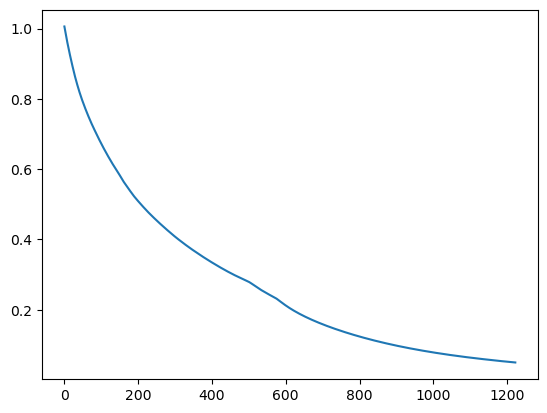

In [11]:
loss_curve = model.loss_curve_
plt.plot(loss_curve)
plt.show()

Perceptron

In [14]:
model_perceptron = Perceptron(max_iter=2000, random_state=42,verbose=True)
model_perceptron.fit(x, y)

-- Epoch 1
Norm: 4.69, NNZs: 8, Bias: 1.000000, T: 14, Avg. loss: 1.142857
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 6.00, NNZs: 9, Bias: 0.000000, T: 28, Avg. loss: 0.428571
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 7.07, NNZs: 10, Bias: -1.000000, T: 42, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 7.62, NNZs: 9, Bias: 2.000000, T: 56, Avg. loss: 0.142857
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 7.62, NNZs: 10, Bias: 1.000000, T: 70, Avg. loss: 0.642857
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 8.37, NNZs: 10, Bias: 1.000000, T: 84, Avg. loss: 0.285714
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 9.06, NNZs: 10, Bias: 1.000000, T: 98, Avg. loss: 0.285714
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 9.49, NNZs: 10, Bias: -1.000000, T: 112, Avg. loss: 0.071429
Total training time: 0.00 seconds.
Convergence after 8 epochs took 0.00 seconds


,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,2000
,tol,0.001
,shuffle,True
,verbose,True
,eta0,1.0
,n_jobs,None
,random_state,42


In [15]:
model_perceptron.score(x, y)

0.6428571428571429

In [17]:
model_perceptron.coef_

array([[ 5., -3., -3., -2., -1.,  2., -4.,  3.,  2., -3.]])

In [18]:
x.columns

Index(['Outlook_Overcast', 'Outlook_Rainy', 'Outlook_Sunny', 'Temp_Cool',
       'Temp_Hot', 'Temp_Mild', 'Humidity_High', 'Humidity_Normal',
       'Windy_False', 'Windy_True'],
      dtype='str')

In [19]:

zipped = zip(x.columns.tolist(), model_perceptron.coef_[0].tolist())
list(zipped)

[('Outlook_Overcast', 5.0),
 ('Outlook_Rainy', -3.0),
 ('Outlook_Sunny', -3.0),
 ('Temp_Cool', -2.0),
 ('Temp_Hot', -1.0),
 ('Temp_Mild', 2.0),
 ('Humidity_High', -4.0),
 ('Humidity_Normal', 3.0),
 ('Windy_False', 2.0),
 ('Windy_True', -3.0)]